## Python For Machine Learning Fall 2025
---
# Artificial Neural Networks (ANNs)

# 1. Overview

Artificial Neural Networks (ANNs), the foundational technology behind deep learning, are computational systems inspired by the interconnected structure of the human brain. These networks are built from layers of processing units called "neurons," which are connected by pathways that function like biological synapses. An ANN typically consists of an input layer that receives raw data (like the pixels of an image or words in a sentence), one or more hidden layers where the data is processed, and an output layer that delivers the final result, such as a classification or prediction. The strength of each connection between neurons is defined by a numerical value called a "weight." ANNs "learn" not by being explicitly programmed with rules, but through a process called training, where they are fed vast amounts of example data. During training, the network continuously adjusts these weights to minimize the difference between its predictions and the actual correct answers, gradually becoming more accurate at recognizing complex patterns, relationships, and features. This pattern-recognition ability makes ANNs extremely powerful for a wide rangeof tasks, including image and speech recognition, natural language processing, and forecasting.

## 1.1 The Biological Inspiration for ANNs
Artificial Neural Networks (ANNs) are directly inspired by the architecture and signal-processing principles of biological neurons. In the brain, a biological neuron receives electrochemical signals from thousands of other neurons through its dendrites; in an ANN, an artificial neuron (or "node") receives numerical values as inputs. These incoming signals are integrated within the neuron's cell body, or soma, and if their combined strength surpasses a specific threshold, the neuron "fires," sending an electrical spike called an action potential down its axon. This all-or-nothing firing mechanism is mathematically modeled in an ANN by an activation function, which processes the sum of the inputs to determine the node's final output signal. The most critical parallel lies in the synapse—the tiny gap between neurons where signals are transmitted. The strength or efficiency of a biological synapse can change over time, a concept known as synaptic plasticity, which is the physical basis of learning and memory. This is the direct inspiration for an ANN's weights, which are numerical values that magnify or diminish each input signal. During the "learning" process, the ANN algorithmically adjusts these weights, effectively strengthening or weakening connections—just as the brain does—to improve the network's overall performance on a given task.

## 1.2 Neurons

Neurons, or nerve cells, are the fundamental units of the brain and nervous system. They are responsible for receiving sensory input from the external world, for sending motor commands to our muscles, and for transforming and relaying the electrical and chemical signals at every step in between. Think of them as the body's biological "wiring" that transmits information.

In [ ]:
from IPython.display import Image
Image(url='https://upload.wikimedia.org/wikipedia/commons/1/10/Blausen_0657_MultipolarNeuron.png', width=800, height=500)

In [ ]:
Image(url='https://media1.tenor.com/m/xal-BhARm3oAAAAd/neurons-neurotransmitters.gif', width=800, height=500)

# 2. The Perceptron

The Perceptron, introduced by Frank Rosenblatt in 1957, is the foundational algorithm and simplest form of an artificial neural network, serving as the "original" artificial neuron. Designed specifically for binary classification, its primary function is to decide whether a given input belongs to one of two classes (e.g., "spam" or "not spam," 1 or 0). It operates by taking multiple numerical inputs, multiplying each by a corresponding weight to signify its importance, and then summing them together. This "weighted sum" is then added to a bias (an offset value that shifts the decision boundary) and passed through a simple activation function—in the classic perceptron, this is a step function. If this final combined value exceeds a certain threshold, the perceptron "fires" and outputs one value (like 1); if it falls below the threshold, it outputs the other (like 0). The perceptron "learns" through a simple training algorithm that iteratively adjusts the weights and bias each time it makes an incorrect prediction, gradually nudging its decision boundary toward one that correctly separates the data. While groundbreaking, the single-layer perceptron's key limitation is that it can only solve linearly separable problems—those where a single straight line (or hyperplane in higher dimensions) can perfectly divide the two

## 2.1 Components

A perceptron is composed of three main parts:

* **Inputs ($x$):** These are the input features for a single data sample. They are represented as a vector:
$$
\mathbf{x} = [x_1, x_2, \dots, x_n]
$$

* **Weights ($w$):** Each input $x_i$ has an associated weight $w_i$. The weight signifies the importance of that input in determining the final output. A larger weight means that input has a greater influence.
$$
\mathbf{w} = [w_1, w_2, \dots, w_n]
$$

* **Bias ($b$):** The bias is a single constant value that is added to the weighted sum. It acts as an adjustable threshold, allowing the activation function's decision boundary to be shifted left or right, which is crucial for the perceptron to learn successfully.

## 2.2 Process

The perceptron's operation is a two-step process: calculating the weighted sum and applying an activation function.

### Weighted Sum ($z$)

First, the perceptron computes the **weighted sum** (also called the *net input* or *logit*) of its inputs. This is done by multiplying each input $x_i$ by its corresponding weight $w_i$, summing these products, and finally adding the bias $b$.

This calculation is represented by the equation:
$$z = (w_1 x_1 + w_2 x_2 + \dots + w_n x_n) + b$$

Using summation notation, this can be written more concisely:
$$z = \sum_{i=1}^{n} (w_i x_i) + b$$

Using vector notation, this is a simple dot product:
$$z = \mathbf{w} \cdot \mathbf{x} + b$$

### Activation Function ($f(z)$)

Second, the weighted sum $z$ is passed through an **activation function** to produce the final output. The classic perceptron uses a **Heaviside step function**, which produces a binary output (0 or 1).

The function is defined as:
$$ \hat{y} = f(z) =
\begin{cases}
  1 & \text{if } z > 0 \\
  0 & \text{if } z \le 0
\end{cases}
$$

* $\hat{y}$ (y-hat) represents the predicted output of the perceptron.
* If the weighted sum $z$ is greater than 0, the perceptron "fires" and outputs **1**.
* If the weighted sum $z$ is less than or equal to 0, the perceptron does not fire and outputs **0**.

Here is a conceptual example of perceptron written in Python.

In [ ]:
def perceptron(inputs, weights, bias):
    # 1. Calculate weighted sum
    weighted_sum = 0
    for i in range(len(inputs)):
        weighted_sum += inputs[i] * weights[i]
    weighted_sum += bias

    # 2. Activation Function (Step Function)
    if weighted_sum > 0:
        return 1
    else:
        return 0

print("Perceptron function defined!")

Perceptron function defined!


## 2.3 Limitation of the Perceptron & The AI Winter

In the late 1950s, Frank Rosenblatt's Perceptron sparked a massive wave of optimism for artificial intelligence. It was hailed as a revolutionary "electronic brain," a machine that could learn from experience just like a biological neuron. This potential captivated the public and, most notably, the U.S. Navy, which invested heavily in the technology, funding the creation of the Mark I Perceptron machine to explore tasks like image recognition. Headlines from the era, such as those in The New York Times, sensationally predicted machines that could soon walk, talk, see, and even become conscious.

This period of intense hype came to an abrupt end in 1969 with the publication of the book **Perceptrons** by Marvin Minsky and Seymour Papert. The authors provided a rigorous mathematical proof that the simple, single-layer perceptron had severe limitations. They famously demonstrated it was incapable of solving a class of "non-linearly separable" problems, with the most famous example being the simple XOR (exclusive OR) logic function. This devastating critique exposed the gap between the machine's actual capabilities and the grand expectations, causing funding to evaporate and researchers to abandon the field. This event effectively triggered the first "AI Winter," a long period of reduced funding and academic interest in neural networks that lasted for decades.

# 3. The Multi-Layer Perceptron (MLP)

A Multilayer Perceptron (MLP) is a foundational type of artificial neural network and a fundamental building block of deep learning. It consists of at least three layers of nodes: an input layer, one or more hidden layers, and an output layer. Each node, or neuron, in one layer is fully connected to every neuron in the next layer, creating a "feedforward" architecture where information flows in only one direction—from input to output. What truly empowers an MLP is the use of a non-linear activation function (like Sigmoid or ReLU) in its hidden neurons. This non-linearity allows the network to learn and model complex, non-linearly separable patterns, overcoming the critical limitation of the single-layer perceptron which could only solve simple linear problems. MLPs are "trained" using a famous algorithm called backpropagation, which calculates the network's prediction error and propagates it backward through the layers, adjusting the weights of the connections to progressively improve the model's accuracy.

The simplest MLP that can solve XOR problem is as follows:

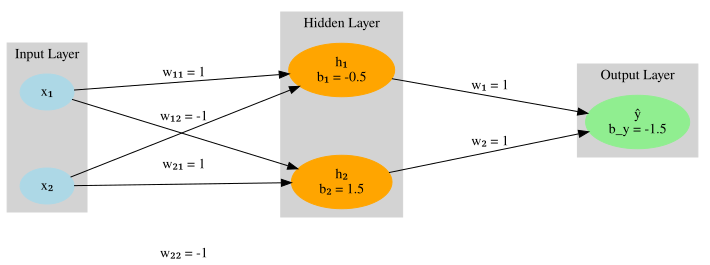

In [ ]:
from graphviz import Digraph

dot = Digraph(comment='MLP for XOR with Parameters')
dot.attr(rankdir='LR', splines='line', nodesep='0.8', ranksep='2')

with dot.subgraph(name='cluster_0') as c:
    c.attr(label='Input Layer', style='filled', color='lightgrey')
    c.node_attr['style'] = 'filled'
    c.node_attr['color'] = 'lightblue'
    c.node('x1', 'x₁')
    c.node('x2', 'x₂')
    c.attr(rank='same')

with dot.subgraph(name='cluster_1') as c:
    c.attr(label='Hidden Layer', style='filled', color='lightgrey')
    c.node_attr['style'] = 'filled'
    c.node_attr['color'] = 'orange'
    c.node('h1', 'h₁\nb₁ = -0.5')
    c.node('h2', 'h₂\nb₂ = 1.5')
    c.attr(rank='same')

with dot.subgraph(name='cluster_2') as c:
    c.attr(label='Output Layer', style='filled', color='lightgrey')
    c.node_attr['style'] = 'filled'
    c.node_attr['color'] = 'lightgreen'
    c.node('y_hat', 'ŷ\nb_y = -1.5')
    c.attr(rank='same')

dot.edge('x1', 'h1', label='w₁₁ = 1')
dot.edge('x2', 'h1', label='w₂₁ = 1')
dot.edge('x1', 'h2', label='w₁₂ = -1')
dot.edge('x2', 'h2', label='w₂₂ = -1')
dot.edge('h1', 'y_hat', label='w₁ = 1')
dot.edge('h2', 'y_hat', label='w₂ = 1')

dot

While this model can solve the XOR problem, it cannot use gradient descent for learning in practical applications if it uses a step function. This is because the step function's derivative is zero, which prevents the parameters from being updated.

The "first comeback" of artificial neural networks (ANNs) was driven by solving two major problems that had crippled early models. The original "perceptron," a single-layer network, was proven to be fundamentally limited. Its resurgence was made possible by the introduction of non-linearity and a training method called backpropagation.

# 4. Non-Linearity via Activation Function

An activation function is a mathematical function f(x) applied to the output of a neuron (or a layer of neurons). Their most important job is to introduce non-linearity into the network. Without activation functions, a neural network, no matter how many layers, would just be a simple linear model. It could only learn to separate data with a straight line. By adding non-linearity, activation functions allow the network to learn far more complex patterns and "bend" the decision boundary.

## 4.1 Common Activation Functions

Here are three of the most common activation functions used in neural networks.


#### Sigmoid (Logistic)

* **Formula:** $\sigma(x) = \frac{1}{1 + e^{-x}}$
* **Output Range:** $(0, 1)$
* **Use:** It "squashes" any real-valued number into a range between 0 and 1. This makes it ideal for the output layer of a **binary classification** problem, as the output can be interpreted as a probability. It's less common in hidden layers today due to the "vanishing gradient" problem.

#### Tanh (Hyperbolic Tangent)

* **Formula:** $f(x) = \tanh(x)$
* **Output Range:** $(-1, 1)$
* **Use:** Tanh is very similar to sigmoid but "squashes" values to a range between -1 and 1. Its key advantage is that its output is **zero-centered**, which can help speed up the training process. It's a popular choice for hidden layers.

#### ReLU (Rectified Linear Unit)

* **Formula:** $f(x) = \max(0, x)$
* **Output Range:** $[0, \infty)$
* **Use:** This is the **most popular activation function** for hidden layers today. It's computationally very simple and efficient: if the input is negative, it outputs 0; if the input is positive, it outputs the input itself. This simplicity helps prevent the vanishing gradient problem and allows models to train much faster.

## 4.2 Visuzlization
The plot below visualizes these three functions so you can see their shapes and output ranges.

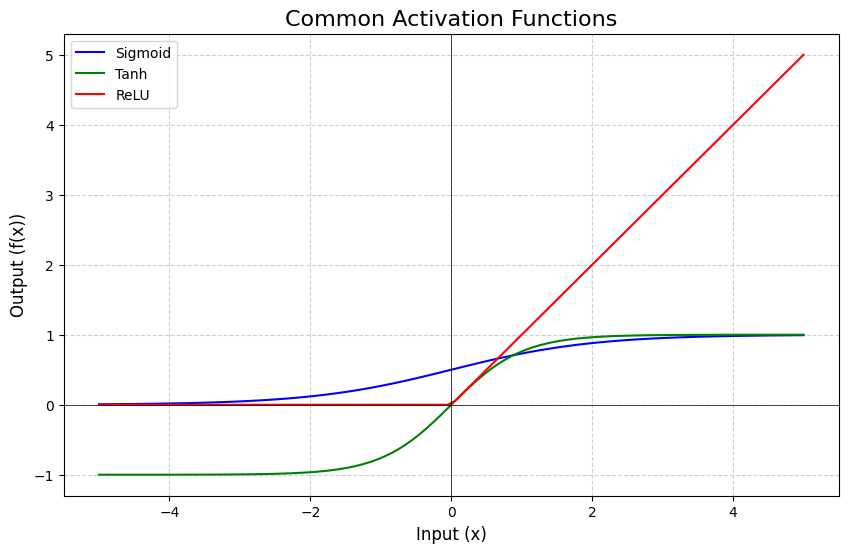

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-5, 5, 100)

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def tanh(x):
    return np.tanh(x)

def relu(x):
    return np.maximum(0, x)

y_sigmoid = sigmoid(x)
y_tanh = tanh(x)
y_relu = relu(x)

plt.figure(figsize=(10, 6))

plt.plot(x, y_sigmoid, label='Sigmoid', color='blue')
plt.plot(x, y_tanh, label='Tanh', color='green')
plt.plot(x, y_relu, label='ReLU', color='red')

plt.title('Common Activation Functions', fontsize=16)
plt.xlabel('Input (x)', fontsize=12)
plt.ylabel('Output (f(x))', fontsize=12)

plt.legend()

plt.grid(True, linestyle='--', alpha=0.6)
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)

plt.show()

In [ ]:
Image(url='https://i0.wp.com/sefiks.com/wp-content/uploads/2020/02/sample-activation-functions-square.png?ssl=1')

#5. Backward Propagation

Gradient descent is the overall optimization algorithm used to train a neural network; its goal is to minimize the loss (or error) by iteratively adjusting the network's weights. To do this, gradient descent needs to know the gradient—the direction of steepest ascent—of the loss function with respect to every single weight in the network. Backpropagation is the specific algorithm that efficiently calculates these gradients. It's the "how-to" for finding the gradients, not the update rule itself. Backpropagation works by applying the chain rule of calculus, starting from the final loss at the output layer and propagating the error backward, layer by layer, to determine how much each individual weight and bias contributed to that error. In short: gradient descent is the optimizer that updates the weights, and backpropagation is the engine that provides the exact gradients it needs to do so.

## 5.1 The Story & Key People
The core idea was discovered by several people independently, but the community recognizes **Paul Werbos**, who proposed the BP algorithm in his 1974 PhD thesis as the inventor.

Other key contributors are:
- The Breakthrough (1986): **David Rumelhart, Geoffrey Hinton, & Ronald Williams** published a paper that clearly explained the backpropagation algorithm and showed it could be used to train MLPs to solve complex problems.

- **Geoffrey Hinton** ("the godfather of AI") became a central figure, championing this approach through the "winter" and mentoring many future leaders.

- **Yann LeCun** (another "godfather") was an early pioneer who, in the late 80s/early 90s, applied backpropagation to MLPs to create "Convolutional Neural Networks" (CNNs) that could famously read handwritten zip codes.

## 5.2 The BP Algorithm

The training process for an MLP is an iterative loop that relies on the **Backpropagation (BP)** algorithm. Each full iteration, or "epoch," consists of two main phases:

* **Phase 1: Forward Propagation (Prediction)**
    This is the straightforward flow of data. The input features are fed into the network, pass through the hidden layers, and produce a final output, or "prediction."
    *(Input $\rightarrow$ Hidden Layers $\rightarrow$ Output Prediction)*

* **Phase 2: Backward Propagation (Learning)**
    This is the core training phase where the network adjusts its internal weights. It's a multi-step process:
    1.  **Calculate Error (Loss):** The network's prediction ($\hat{y}$) is compared to the *actual* correct answer ($y$) using a **loss function** (like MSE) to quantify how "wrong" the prediction was.
    2.  **Backpropagation (Calculate Gradients):** This is the "credit assignment" step. The algorithm uses calculus (specifically, the **chain rule**) to trace the error backward from the loss, layer by layer. This efficiently calculates the **gradient** for every single weight and bias, determining exactly how much each parameter contributed to the total error.
    3.  **Gradient Descent (Update Weights):** The gradients (which point in the direction of *increasing* error) are used by the **gradient descent** optimizer. The optimizer "nudges" each weight in the *opposite* direction, making a small adjustment that will *reduce* the error on the next pass.
    4.  **Repeat:** This entire forward-and-backward cycle is repeated thousands of times. With each iteration, the network's weights are progressively fine-tuned, allowing it to "learn" and become more accurate.

## 5.3 Derivation of the algorithm.

The following is the derivation of the BP algorithm.

### 5.3.1 Setup: Network, Variables, and Loss Function

To derive backpropagation, we must first define our network and notation. We will use a simple 2-2-1 MLP (like the one for XOR) with one hidden layer.

* **Input Layer:** $\mathbf{x} = \begin{bmatrix} x_1 \\ x_2 \end{bmatrix}$
* **Hidden Layer (Layer 1):**
    * Weights & Biases: $\mathbf{W}^{(1)}$ (a 2x2 matrix), $\mathbf{b}^{(1)}$ (a 2x1 vector)
    * Weighted Sum (Logit): $\mathbf{z}^{(1)} = \mathbf{W}^{(1)}\mathbf{x} + \mathbf{b}^{(1)}$
    * Activation: $\mathbf{h} = f(\mathbf{z}^{(1)})$
* **Output Layer (Layer 2):**
    * Weights & Biases: $\mathbf{W}^{(2)}$ (a 1x2 row vector), $b^{(2)}$ (a scalar)
    * Weighted Sum (Logit): $z^{(2)} = \mathbf{W}^{(2)}\mathbf{h} + b^{(2)}$
    * Activation (Prediction): $\hat{y} = f(z^{(2)})$
* **Activation Function:** We'll use a differentiable function $f(z)$, like the **Sigmoid function**, $\sigma(z)$. Its derivative is clean and simple: $f'(z) = f(z)(1 - f(z))$.
* **Loss Function:** We'll use the **Mean Squared Error (MSE)** for a single sample. The $\frac{1}{2}$ simplifies the derivative.
$$L = \frac{1}{2}(y - \hat{y})^2$$

### 5.3.2. The Goal: Gradient Descent

The goal of backpropagation is to find how much our total loss $L$ changes with respect to *every* weight and bias in the network. This "change" is the partial derivative, or **gradient**.

We need to find:
* $\frac{\partial L}{\partial \mathbf{W}^{(2)}}$ (Gradient for output layer weights)
* $\frac{\partial L}{\partial b^{(2)}}$ (Gradient for output layer bias)
* $\frac{\partial L}{\partial \mathbf{W}^{(1)}}$ (Gradient for hidden layer weights)
* $\frac{\partial L}{\partial \mathbf{b}^{(1)}}$ (Gradient for hidden layer bias)

Once we have these gradients, we update our parameters using **gradient descent**:
$$w_{\text{new}} = w_{\text{old}} - \eta \cdot \frac{\partial L}{\partial w}$$
(where $\eta$ is the learning rate)

We find these gradients by applying the **Chain Rule** backward through the network.

### 5.3.3. Backward Pass: Output Layer (Layer 2)

Let's find the gradients for $\mathbf{W}^{(2)}$ and $b^{(2)}$. We trace the path from $L$ back to $\mathbf{W}^{(2)}$ using the chain rule:
$$\frac{\partial L}{\partial \mathbf{W}^{(2)}} = \frac{\partial L}{\partial \hat{y}} \cdot \frac{\partial \hat{y}}{\partial z^{(2)}} \cdot \frac{\partial z^{(2)}}{\partial \mathbf{W}^{(2)}}$$

Let's break this down:

1.  **$\frac{\partial L}{\partial \hat{y}}$:** (How loss changes w.r.t. the prediction)
    $L = \frac{1}{2}(y - \hat{y})^2 \implies \frac{\partial L}{\partial \hat{y}} = 2 \cdot \frac{1}{2}(y - \hat{y}) \cdot (-1) = (\hat{y} - y)$

2.  **$\frac{\partial \hat{y}}{\partial z^{(2)}}$:** (How the activation changes w.r.t. the logit)
    $\hat{y} = f(z^{(2)}) \implies \frac{\partial \hat{y}}{\partial z^{(2)}} = f'(z^{(2)})$

3.  **$\frac{\partial z^{(2)}}{\partial \mathbf{W}^{(2)}}$:** (How the logit changes w.r.t. the weights)
    $z^{(2)} = \mathbf{W}^{(2)}\mathbf{h} + b^{(2)} = (w_1^{(2)}h_1 + w_2^{(2)}h_2) + b^{(2)}$
    The derivative w.r.t. the weight vector is just the input vector that was multiplied by it:
    $\frac{\partial z^{(2)}}{\partial \mathbf{W}^{(2)}} = \mathbf{h}^T$ (the row-vector transpose of $\mathbf{h}$)

**Putting it all together for $\mathbf{W}^{(2)}$:**
Let's define the "output error delta" ($\delta^{(2)}$) as the error gradient at the output logit:
$$\delta^{(2)} = \frac{\partial L}{\partial z^{(2)}} = \frac{\partial L}{\partial \hat{y}} \cdot \frac{\partial \hat{y}}{\partial z^{(2)}} = (\hat{y} - y) \cdot f'(z^{(2)})$$

Now, the gradient for $\mathbf{W}^{(2)}$ is:
$$\frac{\partial L}{\partial \mathbf{W}^{(2)}} = \delta^{(2)} \cdot \mathbf{h}^T$$

**For the bias $b^{(2)}$:**
The derivative $\frac{\partial z^{(2)}}{\partial b^{(2)}} = 1$.
$$\frac{\partial L}{\partial b^{(2)}} = \frac{\partial L}{\partial z^{(2)}} \cdot \frac{\partial z^{(2)}}{\partial b^{(2)}} = \delta^{(2)} \cdot 1 = \delta^{(2)}$$

### 5.3.4. Backward Pass: Hidden Layer (Layer 1)

This is the core of backpropagation. We need to find $\frac{\partial L}{\partial \mathbf{W}^{(1)}}$. The chain is longer:
$$\frac{\partial L}{\partial \mathbf{W}^{(1)}} = \frac{\partial L}{\partial \mathbf{h}} \cdot \frac{\partial \mathbf{h}}{\partial \mathbf{z}^{(1)}} \cdot \frac{\partial \mathbf{z}^{(1)}}{\partial \mathbf{W}^{(1)}}$$

The key is finding $\frac{\partial L}{\partial \mathbf{h}}$, the error at the hidden layer's *output*. The error from $L$ must flow *back through* $z^{(2)}$ and $\mathbf{W}^{(2)}$ to reach $\mathbf{h}$.

1.  **$\frac{\partial L}{\partial \mathbf{h}}$:** (How loss changes w.r.t. hidden activations)
    $$\frac{\partial L}{\partial \mathbf{h}} = \frac{\partial L}{\partial z^{(2)}} \cdot \frac{\partial z^{(2)}}{\partial \mathbf{h}}$$
    * We already know $\frac{\partial L}{\partial z^{(2)}} = \delta^{(2)}$.
    * From $z^{(2)} = \mathbf{W}^{(2)}\mathbf{h} + b^{(2)}$, the derivative w.r.t. $\mathbf{h}$ is just the weight matrix $(\mathbf{W}^{(2)})^T$.
    * So: $\frac{\partial L}{\partial \mathbf{h}} = (\mathbf{W}^{(2)})^T \delta^{(2)}$
    This "propagates" the error from the output layer back to the hidden layer, weighted by the connections.

2.  **$\frac{\partial \mathbf{h}}{\partial \mathbf{z}^{(1)}}$:** (How hidden activation changes w.r.t. hidden logit)
    This is just the element-wise derivative of the activation function: $f'(\mathbf{z}^{(1)})$

**Putting it together for the "hidden error delta" ($\boldsymbol{\delta}^{(1)}$):**
Let's define $\boldsymbol{\delta}^{(1)}$ as the error gradient at the hidden layer logit $\mathbf{z}^{(1)}$:
$$\boldsymbol{\delta}^{(1)} = \frac{\partial L}{\partial \mathbf{z}^{(1)}} = \frac{\partial L}{\partial \mathbf{h}} \odot \frac{\partial \mathbf{h}}{\partial \mathbf{z}^{(1)}}$$
(where $\odot$ is the Hadamard, or element-wise, product)
$$\boldsymbol{\delta}^{(1)} = ((\mathbf{W}^{(2)})^T \delta^{(2)}) \odot f'(\mathbf{z}^{(1)})$$

**Finally, for $\mathbf{W}^{(1)}$:**
$$\frac{\partial L}{\partial \mathbf{W}^{(1)}} = \frac{\partial L}{\partial \mathbf{z}^{(1)}} \cdot \frac{\partial \mathbf{z}^{(1)}}{\partial \mathbf{W}^{(1)}} = \boldsymbol{\delta}^{(1)} \mathbf{x}^T$$
(Just like the output layer, the gradient w.r.t. the weights is the "delta" of that layer multiplied by the "input" to that layer, $\mathbf{x}^T$).

**For the bias $\mathbf{b}^{(1)}$:**
$$\frac{\partial L}{\partial \mathbf{b}^{(1)}} = \frac{\partial L}{\partial \mathbf{z}^{(1)}} \cdot \frac{\partial \mathbf{z}^{(1)}}{\partial \mathbf{b}^{(1)}} = \boldsymbol{\delta}^{(1)} \cdot 1 = \boldsymbol{\delta}^{(1)}$$

### 5.3.5. Summary: The Backpropagation Algorithm

Here is the full algorithm for one training step:

**1. Forward Pass:**
* $\mathbf{z}^{(1)} = \mathbf{W}^{(1)}\mathbf{x} + \mathbf{b}^{(1)}$
* $\mathbf{h} = f(\mathbf{z}^{(1)})$
* $z^{(2)} = \mathbf{W}^{(2)}\mathbf{h} + b^{(2)}$
* $\hat{y} = f(z^{(2)})$
* $L = \frac{1}{2}(y - \hat{y})^2$

**2. Backward Pass (Compute Error Deltas):**
* **Output Delta:** $\delta^{(2)} = (\hat{y} - y) \cdot f'(z^{(2)})$
* **Hidden Delta:** $\boldsymbol{\delta}^{(1)} = ((\mathbf{W}^{(2)})^T \delta^{(2)}) \odot f'(\mathbf{z}^{(1)})$

**3. Calculate Gradients:**
* $\frac{\partial L}{\partial \mathbf{W}^{(2)}} = \delta^{(2)} \mathbf{h}^T$
* $\frac{\partial L}{\partial b^{(2)}} = \delta^{(2)}$
* $\frac{\partial L}{\partial \mathbf{W}^{(1)}} = \boldsymbol{\delta}^{(1)} \mathbf{x}^T$
* $\frac{\partial L}{\partial \mathbf{b}^{(1)}} = \boldsymbol{\delta}^{(1)}$

**4. Update Parameters:**
* $\mathbf{W}^{(2)} = \mathbf{W}^{(2)} - \eta \frac{\partial L}{\partial \mathbf{W}^{(2)}}$
* $b^{(2)} = b^{(2)} - \eta \frac{\partial L}{\partial b^{(2)}}$
* $\mathbf{W}^{(1)} = \mathbf{W}^{(1)} - \eta \frac{\partial L}{\partial \mathbf{W}^{(1)}}$
* $\mathbf{b}^{(1)} = \mathbf{b}^{(1)} - \eta \frac{\partial L}{\partial \mathbf{b}^{(1)}}$

# 6. Neural Networks

A wide variety of neural networks, each with unique features, has emerged based on the structure of neurons.

## 6.1. Multilayer Perceptron (MLP) - The Foundational Network

**Structure Description:**
The MLP, also known as a Dense Neural Network, consists of an input layer, one or more hidden layers, and an output layer. Each neuron in a layer is fully connected to every neuron in the subsequent layer. Information flows strictly in one direction (feedforward). The hidden and output layers use non-linear activation functions to learn complex relationships.

**Use Cases:** Tabular data classification/regression, simple pattern recognition, as the "head" of more complex networks.

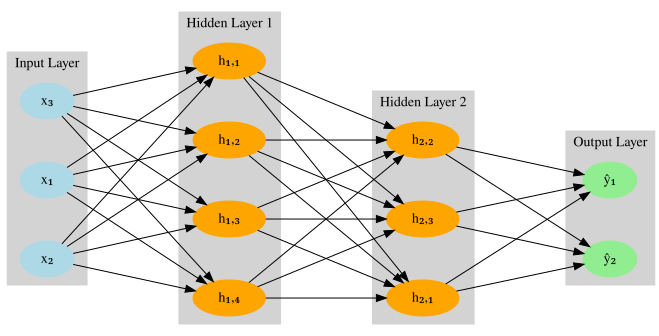

In [ ]:
input_layer_nodes = ['x1', 'x2', 'x3']
input_layer_labels = ['x₁', 'x₂', 'x₃']

hidden_layer_1_nodes = ['h1_1', 'h1_2', 'h1_3', 'h1_4']
hidden_layer_1_labels = ['h₁,₁', 'h₁,₂', 'h₁,₃', 'h₁,₄']

hidden_layer_2_nodes = ['h2_1', 'h2_2', 'h2_3']
hidden_layer_2_labels = ['h₂,₁', 'h₂,₂', 'h₂,₃']

output_layer_nodes = ['y1', 'y2']
output_layer_labels = ['ŷ₁', 'ŷ₂']

dot = Digraph(comment='Multi-Input, Multi-Output MLP')
dot.attr(rankdir='LR', splines='line', nodesep='0.6', ranksep='1.5')

with dot.subgraph(name='cluster_input') as c:
    c.attr(label='Input Layer', style='filled', color='lightgrey')
    c.node_attr['style'] = 'filled'
    c.node_attr['color'] = 'lightblue'
    c.attr(rank='same')
    for name, label in zip(input_layer_nodes, input_layer_labels):
        c.node(name, label)

with dot.subgraph(name='cluster_hidden1') as c:
    c.attr(label='Hidden Layer 1', style='filled', color='lightgrey')
    c.node_attr['style'] = 'filled'
    c.node_attr['color'] = 'orange'
    c.attr(rank='same')
    for name, label in zip(hidden_layer_1_nodes, hidden_layer_1_labels):
        c.node(name, label)

with dot.subgraph(name='cluster_hidden2') as c:
    c.attr(label='Hidden Layer 2', style='filled', color='lightgrey')
    c.node_attr['style'] = 'filled'
    c.node_attr['color'] = 'orange'
    c.attr(rank='same')
    for name, label in zip(hidden_layer_2_nodes, hidden_layer_2_labels):
        c.node(name, label)

with dot.subgraph(name='cluster_output') as c:
    c.attr(label='Output Layer', style='filled', color='lightgrey')
    c.node_attr['style'] = 'filled'
    c.node_attr['color'] = 'lightgreen'
    c.attr(rank='same')
    for name, label in zip(output_layer_nodes, output_layer_labels):
        c.node(name, label)

for i_node in input_layer_nodes:
    for h_node in hidden_layer_1_nodes:
        dot.edge(i_node, h_node)

for h1_node in hidden_layer_1_nodes:
    for h2_node in hidden_layer_2_nodes:
        dot.edge(h1_node, h2_node)

for h_node in hidden_layer_2_nodes:
    for o_node in output_layer_nodes:
        dot.edge(h_node, o_node)

dot

## 6.2. Convolutional Neural Networks (CNNs) - For Image Data

**Structure Description:**
CNNs are specialized for processing grid-like data such as images. Their key components are:

* **Convolutional Layers:** These layers apply a small learnable filter (kernel) that slides across the entire input, performing convolution operations to detect local features like edges, textures, or shapes. This preserves spatial relationships.
* **Pooling Layers (e.g., Max Pooling):** These layers reduce the spatial dimensions (width, height) of the feature maps, making the network more robust to slight shifts in feature position and reducing computational load.
* **Flatten Layer:** After several convolutional and pooling layers, the resulting 2D feature maps are "flattened" into a 1D vector.
* **Dense (MLP) Layers:** The flattened features are then fed into one or more fully connected (Dense) layers for final classification or regression.

**Use Cases:** Image classification, object detection, facial recognition, medical image analysis, video processing.

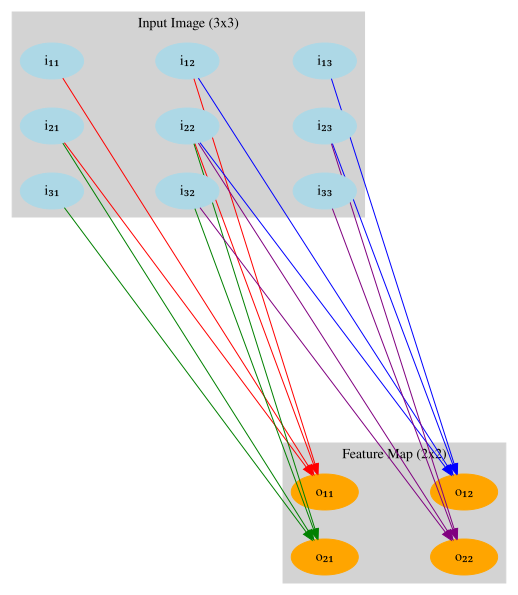

In [ ]:
dot_conv = Digraph(comment='Small-Scale Convolution Mechanism')
dot_conv.attr(rankdir='LR', splines='line', nodesep='0.4', ranksep='1.0')

with dot_conv.subgraph(name='cluster_input') as c:
    c.attr(label='Input Image (3x3)', style='filled', color='lightgrey')
    c.node_attr['style'] = 'filled'
    c.node_attr['color'] = 'lightblue'
    c.node('i_1_1', 'i₁₁')
    c.node('i_1_2', 'i₁₂')
    c.node('i_1_3', 'i₁₃')
    c.node('i_2_1', 'i₂₁')
    c.node('i_2_2', 'i₂₂')
    c.node('i_2_3', 'i₂₃')
    c.node('i_3_1', 'i₃₁')
    c.node('i_3_2', 'i₃₂')
    c.node('i_3_3', 'i₃₃')

    c.edge('i_1_1', 'i_1_2', style='invis')
    c.edge('i_1_2', 'i_1_3', style='invis')
    c.edge('i_2_1', 'i_2_2', style='invis')
    c.edge('i_2_2', 'i_2_3', style='invis')
    c.edge('i_3_1', 'i_3_2', style='invis')
    c.edge('i_3_2', 'i_3_3', style='invis')
    c.attr(rank='same')

with dot_conv.subgraph(name='cluster_output') as c:
    c.attr(label='Feature Map (2x2)', style='filled', color='lightgrey')
    c.node_attr['style'] = 'filled'
    c.node_attr['color'] = 'orange'
    c.node('o_1_1', 'o₁₁')
    c.node('o_1_2', 'o₁₂')
    c.node('o_2_1', 'o₂₁')
    c.node('o_2_2', 'o₂₂')
    c.edge('o_1_1', 'o_1_2', style='invis')
    c.edge('o_2_1', 'o_2_2', style='invis')
    c.attr(rank='same')

dot_conv.edge('i_1_1', 'o_1_1', color='red')
dot_conv.edge('i_1_2', 'o_1_1', color='red')
dot_conv.edge('i_2_1', 'o_1_1', color='red')
dot_conv.edge('i_2_2', 'o_1_1', color='red')

dot_conv.edge('i_1_2', 'o_1_2', color='blue')
dot_conv.edge('i_1_3', 'o_1_2', color='blue')
dot_conv.edge('i_2_2', 'o_1_2', color='blue')
dot_conv.edge('i_2_3', 'o_1_2', color='blue')

dot_conv.edge('i_2_1', 'o_2_1', color='green')
dot_conv.edge('i_2_2', 'o_2_1', color='green')
dot_conv.edge('i_3_1', 'o_2_1', color='green')
dot_conv.edge('i_3_2', 'o_2_1', color='green')

dot_conv.edge('i_2_2', 'o_2_2', color='purple')
dot_conv.edge('i_2_3', 'o_2_2', color='purple')
dot_conv.edge('i_3_2', 'o_2_2', color='purple')
dot_conv.edge('i_3_3', 'o_2_2', color='purple')

dot_conv

## 6.3. Recurrent Neural Networks (RNNs) - For Sequential Data

**Structure Description:**
RNNs are designed to process sequences of data by maintaining an internal "memory" or "hidden state" that captures information from previous steps in the sequence. Unlike feedforward networks, RNNs have loops, where the output of a neuron is fed back into itself at the next timestep.

The most common types, like **Long Short-Term Memory (LSTM)** and **Gated Recurrent Unit (GRU)**, use sophisticated "gates" to control the flow of information into and out of this memory, allowing them to learn long-range dependencies and mitigate the vanishing gradient problem.

**Unrolled View:** When visualizing, RNNs are often shown "unrolled" over time, where each step represents the network processing one element of the sequence, with its hidden state being passed to the next step.

**Use Cases:** Natural Language Processing (NLP - e.g., machine translation, text generation), time-series prediction, speech recognition.

---

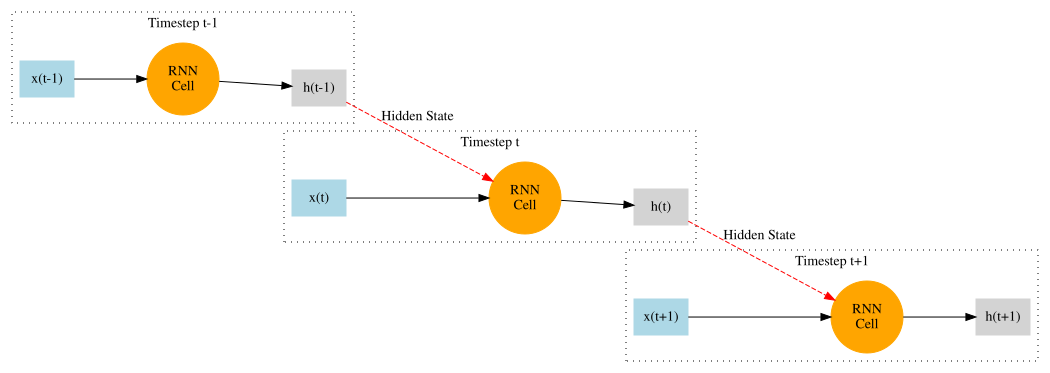

In [ ]:
from graphviz import Digraph

dot_rnn = Digraph(comment='Simplified Unrolled RNN Structure')
dot_rnn.attr(rankdir='LR', splines='line', nodesep='0.5', ranksep='1.0')

with dot_rnn.subgraph(name='cluster_t-1') as c:
    c.attr(label='Timestep t-1', style='dotted')
    c.node('x_t-1', 'x(t-1)', shape='box', style='filled', color='lightblue')
    c.node('rnn_t-1', 'RNN\nCell', shape='circle', style='filled', color='orange', width='1.0', height='0.7')
    c.node('h_t-1_out', 'h(t-1)', shape='box', style='filled', color='lightgray')
    c.attr(rank='same')

with dot_rnn.subgraph(name='cluster_t') as c:
    c.attr(label='Timestep t', style='dotted')
    c.node('x_t', 'x(t)', shape='box', style='filled', color='lightblue')
    c.node('rnn_t', 'RNN\nCell', shape='circle', style='filled', color='orange', width='1.0', height='0.7')
    c.node('h_t_out', 'h(t)', shape='box', style='filled', color='lightgray')
    c.attr(rank='same')

with dot_rnn.subgraph(name='cluster_t+1') as c:
    c.attr(label='Timestep t+1', style='dotted')
    c.node('x_t+1', 'x(t+1)', shape='box', style='filled', color='lightblue')
    c.node('rnn_t+1', 'RNN\nCell', shape='circle', style='filled', color='orange', width='1.0', height='0.7')
    c.node('h_t+1_out', 'h(t+1)', shape='box', style='filled', color='lightgray')
    c.attr(rank='same')

dot_rnn.edge('x_t-1', 'rnn_t-1')
dot_rnn.edge('rnn_t-1', 'h_t-1_out')

dot_rnn.edge('x_t', 'rnn_t')
dot_rnn.edge('rnn_t', 'h_t_out')

dot_rnn.edge('x_t+1', 'rnn_t+1')
dot_rnn.edge('rnn_t+1', 'h_t+1_out')

dot_rnn.edge('h_t-1_out', 'rnn_t', color='red', style='dashed', label='Hidden State')
dot_rnn.edge('h_t_out', 'rnn_t+1', color='red', style='dashed', label='Hidden State')

dot_rnn

## 6.4. Hopfield Networks - For Associative Memory

**Structure Description:**
A **Hopfield Network** is a single-layer, recurrent network where every neuron is connected to every other neuron. It's a form of "content-addressable memory," meaning you can retrieve a full memory (a stored pattern) by providing it with only a partial or noisy version of that pattern.

The network operates by having its neurons' states (e.g., -1 or 1) repeatedly update based on the states of the other neurons until the network settles into a stable "energy" minimum. These stable states represent the stored memories. A key feature is that the connection weights are **symmetric** ($w_{ij} = w_{ji}$).

**Use Cases:** Associative memory (pattern completion, error correction), solving optimization problems.

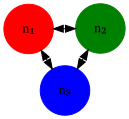

In [ ]:
dot_hopfield = Digraph(comment='Hopfield Network Structure')
dot_hopfield.attr(layout='neato', nodesep='0.3', ranksep='0.3')
dot_hopfield.node('n1', 'n₁', shape='circle', style='filled', color='red')
dot_hopfield.node('n2', 'n₂', shape='circle', style='filled', color='green')
dot_hopfield.node('n3', 'n₃', shape='circle', style='filled', color='blue')

dot_hopfield.edge('n1', 'n2', dir='both')
dot_hopfield.edge('n1', 'n3', dir='both')
dot_hopfield.edge('n2', 'n3', dir='both')

dot_hopfield

## 6.5. Boltzmann Machines - For Probabilistic Modeling

**Structure Description:**
A **Boltzmann Machine** is a generative, stochastic (probabilistic) neural network, also featuring symmetric connections like a Hopfield network. Its key distinction is that neurons update their state based on a probability distribution, which allows the network to model complex data distributions.

The most famous variant is the **Restricted Boltzmann Machine (RBM)**. An RBM is "restricted" in a specific way: it has one layer of **"Visible Units"** (for the input data) and one layer of **"Hidden Units"** (for feature extraction). The restriction is crucial: **there are no connections *within* a layer** (i.e., visible units don't connect to each other, and hidden units don't connect to each other). Connections only exist *between* the visible and hidden layers.

**Use Cases:** Collaborative filtering (recommender systems), feature learning, dimensionality reduction, and as the building blocks for Deep Belief Networks (DBNs).

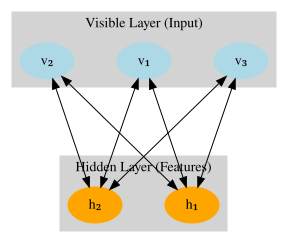

In [ ]:
dot_rbm = Digraph(comment='Restricted Boltzmann Machine (RBM)')
dot_rbm.attr(rankdir='TB', splines='line', nodesep='0.6', ranksep='1.5')

with dot_rbm.subgraph(name='cluster_visible_rbm') as c:
    c.attr(label='Visible Layer (Input)', style='filled', color='lightgrey')
    c.node_attr['style'] = 'filled'
    c.node_attr['color'] = 'lightblue'
    c.node('v1', 'v₁')
    c.node('v2', 'v₂')
    c.node('v3', 'v₃')
    c.attr(rank='same')

with dot_rbm.subgraph(name='cluster_hidden_rbm') as c:
    c.attr(label='Hidden Layer (Features)', style='filled', color='lightgrey')
    c.node_attr['style'] = 'filled'
    c.node_attr['color'] = 'orange'
    c.node('h1', 'h₁')
    c.node('h2', 'h₂')
    c.attr(rank='same')

dot_rbm.edge('v1', 'h1', dir='both')
dot_rbm.edge('v1', 'h2', dir='both')

dot_rbm.edge('v2', 'h1', dir='both')
dot_rbm.edge('v2', 'h2', dir='both')

dot_rbm.edge('v3', 'h1', dir='both')
dot_rbm.edge('v3', 'h2', dir='both')

dot_rbm

## 6.6. Variational Autoencoders (VAEs) - For Generative Modeling

**Structure Description:**
A **Variational Autoencoder (VAE)** is a powerful generative network based on the architecture of an Autoencoder (which has an **Encoder** and a **Decoder**).

* **Encoder:** This part compresses the input data (like an image) into a compressed representation, known as the "latent space." Unlike a standard autoencoder which outputs a single vector, the VAE encoder outputs the parameters of a probability distribution—specifically, a vector of **means ($\mu$)** and a vector of **standard deviations ($\sigma$)**.
* **Bottleneck (Sampling):** A vector $\mathbf{z}$ is then *sampled* from this distribution (e.g., $\mathcal{N}(\mu, \sigma)$). This step introduces randomness, which is key to its generative power.
* **Decoder:** This part takes the sampled latent vector $\mathbf{z}$ and attempts to reconstruct the original input.

By forcing the network to learn a probabilistic distribution for the latent space, VAEs create a *continuous* and *structured* space. This allows you to generate new, novel data (e.g., new faces) by simply sampling a random $\mathbf{z}$ vector from the distribution and feeding it to the decoder.

**Use Cases:** Generative modeling (image/music generation), semi-supervised learning, data compression, and learning a smooth representation of data.

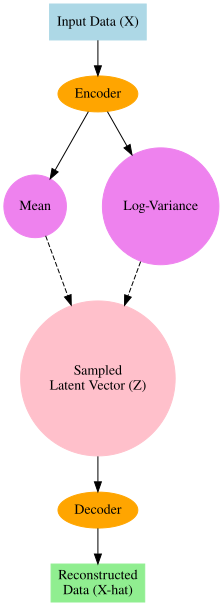

In [ ]:
dot = Digraph(comment='Simple VAE Structure')
dot.attr(rankdir='TB', nodesep='0.5', ranksep='0.5')

dot.node('input_x', 'Input Data (X)', shape='box', style='filled', color='lightblue')
dot.node('encoder_nn', 'Encoder', shape='ellipse', style='filled', color='orange')

dot.node('mu', 'Mean', shape='circle', style='filled', color='violet')
dot.node('log_var', 'Log-Variance', shape='circle', style='filled', color='violet')
dot.node('sample_z', 'Sampled\nLatent Vector (Z)', shape='circle', style='filled', color='pink')

dot.node('decoder_nn', 'Decoder', shape='ellipse', style='filled', color='orange')
dot.node('output_x_hat', 'Reconstructed\nData (X-hat)', shape='box', style='filled', color='lightgreen')

dot.edge('input_x', 'encoder_nn')

dot.edge('encoder_nn', 'mu')
dot.edge('encoder_nn', 'log_var')

dot.edge('mu', 'sample_z', style='dashed')
dot.edge('log_var', 'sample_z', style='dashed')

dot.edge('sample_z', 'decoder_nn')
dot.edge('decoder_nn', 'output_x_hat')

dot